# Integrative Analysis of Breast Cancer Susceptibility Loci and Tumor Immune Programs Reveals Immune-Associated Candidate Genes in Triple-Negative Breast Cancer
---
## Notebook 5 - Integrative Prioritization of Candidate Breast Cancer Susceptibility Genes


### Biological Objective

Genome-wide association studies (GWAS) identify inherited loci associated with breast cancer susceptibility, whereas differential expression analysis identifies genes transcriptionally altered within established tumors. Although both approaches provide valuable biological insight, they represent distinct layers of disease biology.

This notebook integrates these complementary datasets to identify genes that satisfy both criteria:

- located within inherited breast cancer susceptibility loci, and
- significantly dysregulated in Triple-Negative Breast Cancer (TNBC).

Genes meeting both criteria represent high-priority candidates that may contribute to both inherited disease risk and tumor progression.

In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2

### 1. Load GWAS and Transcriptomic Candidate Gene Sets

Candidate susceptibility genes identified from genome-wide significant GWAS loci (Notebook 2) are compared with differentially expressed genes identified from TCGA-BRCA transcriptomic analysis (Notebook 4).

The filtered RNA-seq count matrix is also loaded to define the background gene universe required for statistical enrichment testing.

In [2]:
gwas_genes_df = pd.read_csv("../data/gwas/gwas_mapped_unique_genes.csv")
compiled_degs_df = pd.read_csv("../results/tables/dysregulated_brca_tnbc_compiled_degs.csv")
counts = pd.read_csv("../data/rna_seq/brca_counts_cleaned.csv", index_col=0)

### 2. Identify Genes Shared Between Germline Risk and Tumor Biology

Genes are converted into mathematical sets to enable efficient comparison.

The intersection represents genes that are simultaneously:

- genetically associated with breast cancer susceptibility, and
- transcriptionally dysregulated in TNBC tumors.

These overlapping genes form the primary candidates for downstream biological investigation.

In [3]:
tnbc_set = set(compiled_degs_df['gene_name'].dropna().tolist())
print(f"Loaded TRUE TNBC transcriptomic signature containing {len(tnbc_set)} functional DEGs.")
print('\n')

gwas_set = set(gwas_genes_df['gene_name'].dropna().tolist())
print(f"Loaded {len(gwas_set)} unique GWAS risk genes.")
print('\n')

overlapping_genes = gwas_set.intersection(tnbc_set)
print(f"Found {len(overlapping_genes)} genes shared between germline risk and TNBC tumor biology!")
print(f"Shared genes: {list(overlapping_genes)}")

Loaded TRUE TNBC transcriptomic signature containing 2947 functional DEGs.


Loaded 193 unique GWAS risk genes.


Found 20 genes shared between germline risk and TNBC tumor biology!
Shared genes: ['SLC35F2', 'FGF11', 'CPAMD8', 'PTHLH', 'COL11A2', 'ALK', 'KIFC1', 'NIBAN3', 'HNF1A', 'ESR1', 'RMND1', 'FBXO32', 'ANKLE1', 'TOX3', 'RAD51B', 'PCARE', 'TERT', 'CDKN2A', 'CCDC170', 'KLF5']


In [4]:
min_samples = int(0.10 * counts.shape[1])
passed_filter_mask = (counts >= 10).sum(axis=1) >= min_samples
counts_filtered = counts[passed_filter_mask]
counts_filtered = counts_filtered[~counts_filtered.index.duplicated(keep='first')]

## 3. Evaluate Whether the Observed Overlap Exceeds Random Expectation

Some overlap between two gene lists is expected simply by chance.

To determine whether the observed intersection is larger than expected under random sampling, a hypergeometric enrichment test is performed.

Definitions:

- **Background universe (M):** all expressed protein-coding genes passing expression filtering
- **GWAS candidate genes (n):** susceptibility genes represented in the expression background
- **TNBC DEGs (N):** significantly dysregulated genes
- **Observed overlap (x):** genes present in both datasets

A statistically significant result would suggest that inherited susceptibility genes are preferentially dysregulated in TNBC tumors.

In [5]:
M = counts_filtered.shape[0]  
n = len(gwas_set.intersection(counts_filtered.index))  
N = len(tnbc_set)                                      
x = len(overlapping_genes)                             

p_val_overlap = stats.hypergeom.sf(x - 1, M, n, N)
print(f"\nHypergeometric overlap p-value: {p_val_overlap:.6e}")


Hypergeometric overlap p-value: 9.913025e-01


### Interpretation of the Hypergeometric Test

A hypergeometric test was performed to determine whether breast cancer susceptibility genes identified by GWAS were enriched among genes differentially expressed in TNBC.

The observed overlap (20 genes) was **not significantly greater than expected by chance** (hypergeometric test, *p* ≈ 0.99). This indicates that, at the genome-wide level, inherited susceptibility genes are not globally overrepresented among TNBC differentially expressed genes.

Although no significant enrichment was observed, the overlapping genes remain biologically relevant because each is supported by two independent lines of evidence:

- association with inherited breast cancer susceptibility (GWAS), and
- altered expression in TNBC tumors (RNA-seq).

These genes are therefore retained as high-priority candidates for downstream functional analyses.

### 4. Visualize the Relationship Between Germline and Somatic Gene Sets

A Venn diagram summarizes the overlap between:

- breast cancer susceptibility genes identified by GWAS, and
- genes differentially expressed in TNBC.

The overlapping region highlights genes supported by both inherited genetic evidence and tumor transcriptomic evidence.

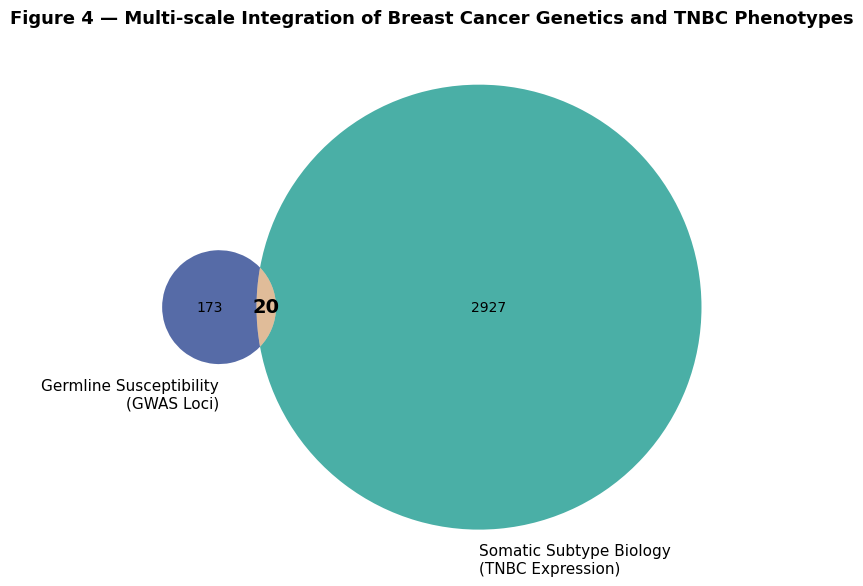

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))


gwas_unique = len(gwas_set) - len(overlapping_genes)
tnbc_unique = len(tnbc_set) - len(overlapping_genes)
intersection_count = len(overlapping_genes)

venn = venn2(
    subsets=(gwas_unique, tnbc_unique, intersection_count),
    set_labels=('Germline Susceptibility\n(GWAS Loci)', 'Somatic Subtype Biology\n(TNBC Expression)'),
    ax=ax
)

if venn.get_label_by_id('A'): 
    venn.get_label_by_id('A').set_fontsize(11)
if venn.get_label_by_id('B'): 
    venn.get_label_by_id('B').set_fontsize(11)
if venn.get_label_by_id('11'): 
    venn.get_label_by_id('11').set_fontsize(14)
    venn.get_label_by_id('11').set_fontweight('bold')

if venn.patches[0]: 
    venn.patches[0].set_facecolor('#1E3A8A')
    venn.patches[0].set_alpha(0.75)
if venn.patches[1]: 
    venn.patches[1].set_facecolor('#0D9488') 
    venn.patches[1].set_alpha(0.75)

ax.set_title("Figure 4 — Multi-scale Integration of Breast Cancer Genetics and TNBC Phenotypes", 
             fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../results/figures/gwas_tnbc_venn_overlap.png', dpi=300, bbox_inches='tight')

### 5. Prioritize Integrated Candidate Genes

Genes present in both datasets are retained as high-confidence candidates for downstream functional characterization.

These genes represent the strongest evidence-supported targets because they combine:

- inherited genetic susceptibility, and
- altered transcriptional activity within TNBC tumors.

The resulting candidate list will be carried forward into immune pathway association analyses.

In [7]:
prioritized_df = gwas_genes_df[gwas_genes_df['gene_name'].isin(overlapping_genes)].copy()
prioritized_df.to_csv("../results/tables/overlapping_genes.csv", index=False)

### Notebook Summary

#### Biological Question Addressed

Which inherited breast cancer susceptibility genes are also transcriptionally altered in Triple-Negative Breast Cancer?

#### Inputs

- GWAS susceptibility genes (Notebook 2)
- Differentially expressed genes (Notebook 4)

#### Analyses Performed

- Gene set intersection
- Hypergeometric overlap test
- Venn diagram visualization
- Candidate gene prioritization

#### Key Results

- **193** GWAS susceptibility genes
- **2,947** TNBC differentially expressed genes
- **20** overlapping candidate genes identified

Examples include:

- NIBAN3
- KLF5
- CDKN2A
- RAD51B
- ANKLE1
- ALK
- TERT
- FBXO32
- TOX3
- ESR1

The hypergeometric test indicated that the observed overlap was not greater than expected by chance, suggesting that widespread enrichment of GWAS susceptibility genes among TNBC DEGs was not observed. Nevertheless, the overlapping genes remain biologically important because each is independently supported by both inherited genetic association and tumor transcriptional dysregulation.

#### Output Generated

- `overlapping_genes.csv`